In [3]:
#### Code to Convert AutoSales.xlsx into AutoSalesDBInsert.xlsx

import os
import pandas as pd
from openpyxl import Workbook, load_workbook
from openpyxl.styles import numbers
from datetime import datetime

def create_auto_sales_table():
    input_file_path = r"C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\AutoSales.xlsx"
    output_file_path = r"C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\AutoSalesDBInsert.xlsx"

    # Load workbook and sheet
    wb = load_workbook(input_file_path, data_only=True)
    sheet = wb["AutoMonthly"]

    # Extract header row (row 2 in Excel = index 1)
    header_row = sheet[2]
    headers = []
    for cell in header_row[2:]:  # Skip first two columns
        if cell.is_date:
            headers.append(cell.value.strftime('%Y-%m-%d'))
        else:
            headers.append(str(cell.value))

    # Prepare new workbook
    if os.path.exists(output_file_path):
        os.remove(output_file_path)
    new_wb = Workbook()
    new_ws = new_wb.active
    new_ws.title = "AutoSalesDBInsert"

    # Write new headers
    new_ws.append(["Date", "Company", "Parameter", "Sales", "3M", "6M", "12M"])

    # Read data rows
    rows = list(sheet.iter_rows(min_row=3, values_only=True))
    last_parameter = None
    skip3M = skip6M = skip12M = 0
    row_index = 2  # Excel row index in new sheet (starts at 2 since row 1 is header)

    for row in rows:
        company = row[0]
        parameter = row[1]

        if parameter != last_parameter:
            last_parameter = parameter
            skip3M = 2
            skip6M = 5
            skip12M = 11

        for i, sales in enumerate(row[2:]):
            date = headers[i]

            # Write row
            new_row = [date, company, parameter]
            new_row.append(sales)

            # Calculate 3M/6M/12M - only when skips are zero
            sales_list = list(row[2:])
            val_3m = sum(x for x in sales_list[max(0, i-2):i+1] if isinstance(x, (int, float))) if skip3M == 0 else ""
            val_6m = sum(x for x in sales_list[max(0, i-5):i+1] if isinstance(x, (int, float))) if skip6M == 0 else ""
            val_12m = sum(x for x in sales_list[max(0, i-11):i+1] if isinstance(x, (int, float))) if skip12M == 0 else ""

            new_row.extend([val_3m, val_6m, val_12m])
            new_ws.append(new_row)

            # Format sales column (comma formatting is handled at Excel side)
            row_index += 1

            skip3M = max(0, skip3M - 1)
            skip6M = max(0, skip6M - 1)
            skip12M = max(0, skip12M - 1)

    # Save workbook
    new_wb.save(output_file_path)
    print("Excel file created successfully!")

# Run it
create_auto_sales_table()

Excel file created successfully!


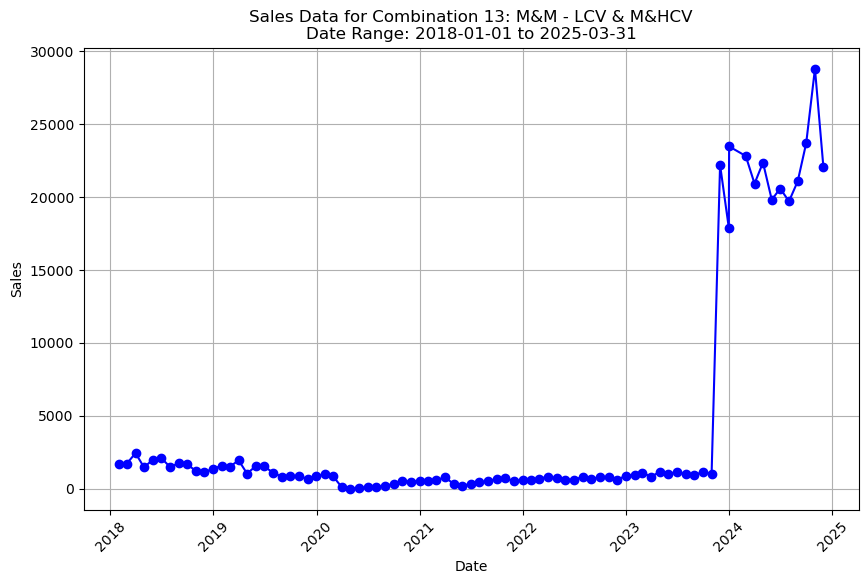

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Choose a combination number
chosen_combination = 13  # You can change this to the desired combination number
# 1, 5, 7, 9, 11, 12, 15, 17, 18, 22, 23, 24, 33, 34, 35, 38, 42, 39, 43, 46, 47, 54, 55, 57, 59, 60, 63, 66, 69

# Set the date range
start_date = '2018-01-01'  # Change this to your desired start date
end_date = '2025-03-31'  # Change this to your desired end date

# Define the combinations as a dictionary with combination numbers
combinations = {
    1 : ('Maruti Suzuki','Total'), 
    2 : ('Maruti Suzuki','LCV'),
    3 : ('Maruti Suzuki','Vans'),
    4 : ('Maruti Suzuki','Mini Segment'),
    5 : ('Maruti Suzuki','Compact'),
    6 : ('Maruti Suzuki','Mid Size - CIAZ'),
    7 : ('Maruti Suzuki','Uvs'),
    8 : ('Maruti Suzuki','Total Domestic'),
    9 : ('Maruti Suzuki','Export'),
    10 : ('Maruti Suzuki','Verify Total'),
    11 : ('M&M','Total'),
    12 : ('M&M','UV (inc. Pickups)'),
    13 : ('M&M','LCV & M&HCV'),
    14 : ('M&M','3-W'),
    15 : ('M&M','Tractors'),
    16 : ('M&M','Verify Total'),
    17 : ('Escort','Total'),
    18 : ('Ashok Layland','Total'),
    19 : ('Ashok Layland','Total M&HCV '),
    20 : ('Ashok Layland','LCV'),
    21 : ('Ashok Layland','Verify Total'),
    22 : ('Eicher Motors','Royal Enfield'),
    23 : ('Eicher Motors','Royal Enfield Export'),
    24 : ('Eicher Motors','VECE Total'),
    25 : ('Eicher Motors','LMD'),
    26 : ('Eicher Motors','HD'),
    27 : ('Eicher Motors','Buses (LMD+LD)'),
    28 : ('Eicher Motors','VTI'),
    29 : ('Eicher Motors','VECE Domestic'),
    30 : ('Eicher Motors','Verify Domestic'),
    31 : ('Eicher Motors','VECE Export'),
    32 : ('Eicher Motors','Verify Total'),
    33 : ('Bajaj Auto','Total'),
    34 : ('Bajaj Auto','2-W'),
    35 : ('Bajaj Auto','3-W'),
    36 : ('Bajaj Auto','Verify Total'),
    37 : ('Bajaj Auto','Verify Total (Dom + Export)'),
    38 : ('Bajaj Auto','Domestic Total'),
    39 : ('Bajaj Auto','2-W - Domestic'),
    40 : ('Bajaj Auto','3-W - Domestic'),
    41 : ('Bajaj Auto','Verify Domestic Total'),
    42 : ('Bajaj Auto','Export Total'),
    43 : ('Bajaj Auto','2-W - Export'),
    44 : ('Bajaj Auto','3-W - Export'),
    45 : ('Bajaj Auto','Verify  Exports Total'),
    46 : ('TVS','Total'),
    47 : ('TVS','2-W Total'),
    48 : ('TVS','Motorcycle'),
    49 : ('TVS','Scooters'),
    50 : ('TVS','Moped'),
    51 : ('TVS','3-W Total'),
    52 : ('TVS','Verify Total'),
    53 : ('TVS','Total Domestic'),
    54 : ('TVS','Total Domestic - 2-W'),
    55 : ('TVS','Total Exports'),
    56 : ('TVS','Verify Total (Dom + Export)'),
    57 : ('TVS','2-W - Export'),
    58 : ('TVS','3-W - Export'),
    59 : ('Hero Motocorp','Total '),
    60 : ('Tata Motors','Total'),
    63 : ('Tata Motors','Total CV'),
    66 : ('Tata Motors','Total PV'),
    69 : ('Tata Motors','EV (IB + Domestic)'),
}

# Suppress openpyxl warning
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl.styles")

# Read the Excel file
file_path = r'C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\AutoSalesDBInsert.xlsx'
df = pd.read_excel(file_path, parse_dates=['Date'])

# Get the chosen combination from the dictionary
selected_company, selected_parameter = combinations[chosen_combination]

# Filter the DataFrame based on the chosen combination and date range
filtered_df = df[(df['Company'] == selected_company) & (df['Parameter'] == selected_parameter) & (df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['Date'], filtered_df['Sales'], marker='o', linestyle='-', color='b')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title(f'Sales Data for Combination {chosen_combination}: {selected_company} - {selected_parameter}\nDate Range: {start_date} to {end_date}')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

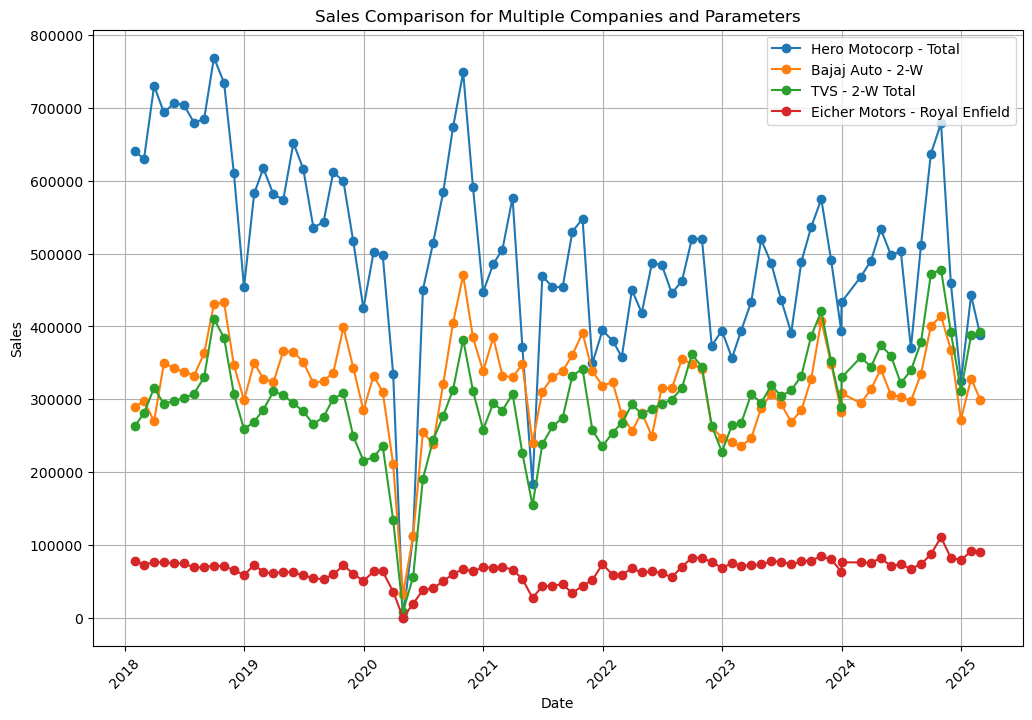

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the Excel file
file_path = r'C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\AutoSalesDBInsert.xlsx'
df = pd.read_excel(file_path, parse_dates=['Date'])

# Define the date range
start_date = '2018-01-01'
end_date = '2025-03-31'

# Define the companies and parameters
companies = ['Hero Motocorp', 'Bajaj Auto', 'TVS', 'Eicher Motors' ]
parameters = ['Total ', '2-W', '2-W Total', 'Royal Enfield']

# Plot the lines
plt.figure(figsize=(12, 8))

for company, parameter in zip(companies, parameters):
    filtered_df = df[(df['Company'] == company) & (df['Parameter'] == parameter) & (df['Date'] >= start_date) & (df['Date'] <= end_date)]
    plt.plot(filtered_df['Date'], filtered_df['Sales'], marker='o', linestyle='-', label=f'{company} - {parameter}')

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Comparison for Multiple Companies and Parameters')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

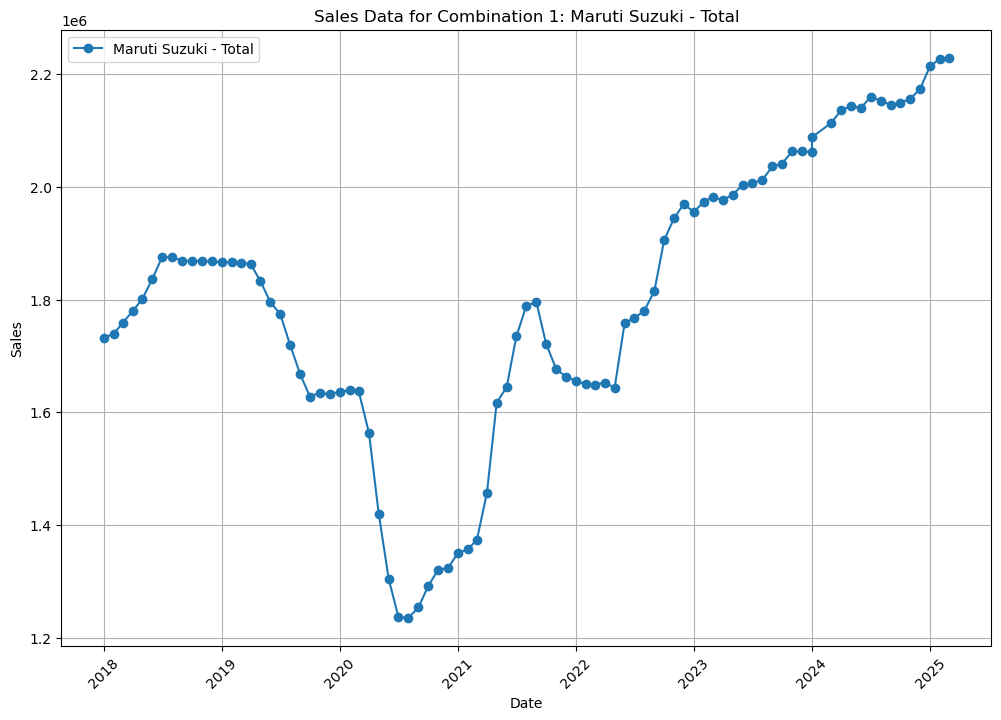

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the Excel file
file_path = r'C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\AutoSalesDBInsert.xlsx'
df = pd.read_excel(file_path, parse_dates=['Date'])

# Choose a combination number
chosen_combination = 1  # You can change this to the desired combination number

# Get the chosen combination from the dictionary
chosen_company, chosen_parameter = combinations[chosen_combination]

# Filter the DataFrame based on the chosen combination
filtered_df = df[(df['Company'] == chosen_company) & (df['Parameter'] == chosen_parameter)]

# Plot the line chart
plt.figure(figsize=(12, 8))
plt.plot(filtered_df['Date'], filtered_df['12M'], marker='o', linestyle='-', label=f'{chosen_company} - {chosen_parameter}')

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title(f'Sales Data for Combination {chosen_combination}: {chosen_company} - {chosen_parameter}')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()